flow mask vs vanilla Dinov2-base

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from pathlib import Path
import torchvision.transforms.v2 as v2
from transformers import AutoModel
from model_finetune import get_robust_mask, get_robust_mask_2

I0000 00:00:1779318453.190202  143713 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779318453.236924  143713 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779318454.640158  143713 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779318454.640974  143713 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.

In [2]:
%pwd
%cd ..

/data/pbk5339/thesis/DiffTrack


/scratch/pbk5339/conda_envs/difftrack/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


Loaded flow: torch.Size([120, 2, 224, 224]) from ucfrep_intermediate_dataset/v_Biking_g04_c03/flow.pt
Flow mask shape: torch.Size([1, 3, 1, 224, 224])
Flow mask value range: [0.00, 1.00]


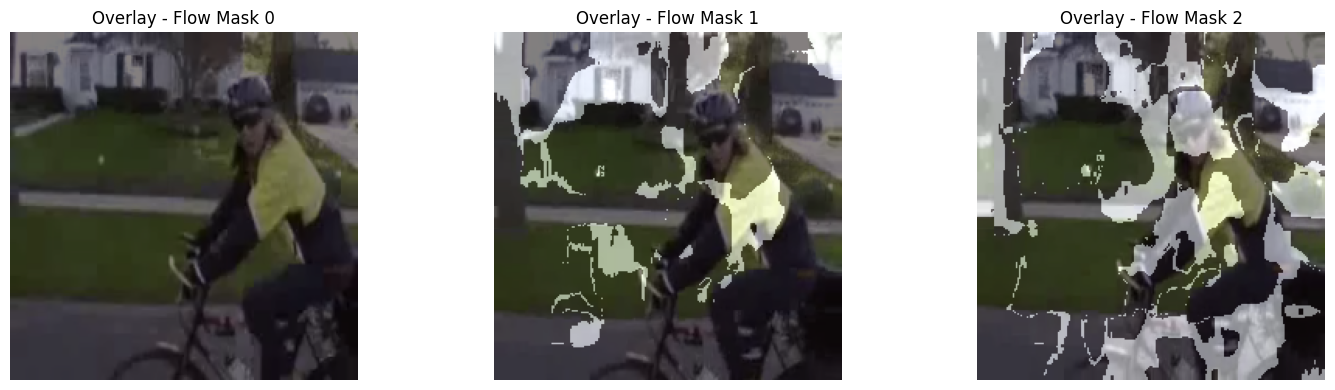

In [3]:

pt_dir = "ucfrep_intermediate_dataset"
selected_video = "v_Biking_g04_c03" 

video_path = os.path.join(pt_dir, selected_video)
flow_path = os.path.join(video_path, "flow.pt")

if not os.path.isdir(video_path):
    raise FileNotFoundError(f"Video folder not found: {video_path}")
if not os.path.isfile(flow_path):
    raise FileNotFoundError(f"flow.pt not found: {flow_path}")

flow = torch.load(flow_path, map_location="cpu")  #(3, 2, 224, 224) ; as the .pt file is laoded with 3 frames
print(f"Loaded flow: {flow.shape} from {flow_path}")

# Choose 3 consecutive frames for flow-mask computation
start_frame = 0  # change this if you want a different chunk
if flow.shape[0] < 3:
    raise ValueError("Not enough frames in flow.pt (need at least 3)")

frame_chunk_indices = [start_frame, start_frame + 1, start_frame + 2]
flow_chunk = flow[frame_chunk_indices].unsqueeze(0)  # (1, 3, 2, 224, 224)

#get flow mask
flow_mask = get_robust_mask_2(flow_chunk)  # (1, 3, 1, 224, 224)
print(f"Flow mask shape: {flow_mask.shape}")
print(f"Flow mask value range: [{flow_mask.min():.2f}, {flow_mask.max():.2f}]")

# # Visualize
# fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# for i, frame_idx in enumerate(frame_chunk_indices):
#     mask = flow_mask[0, i, 0].numpy()
#     axes[i].imshow(mask, cmap="hot")
#     axes[i].set_title(f"Flow Mask - Frame {frame_idx}")
#     axes[i].axis("off")

# plt.tight_layout()
# plt.show()

# print("\nFlow mask statistics:")
# for i, frame_idx in enumerate(frame_chunk_indices):
#     mask = flow_mask[0, i, 0].numpy()
#     print(f"  Frame {frame_idx}: min={mask.min():.3f}, max={mask.max():.3f}, mean={mask.mean():.3f}, active_pixels={np.count_nonzero(mask)}")


#for overlay
mp4_dir = "UCF_Rep/train"
mp4_path = os.path.join(mp4_dir, selected_video + ".mp4")

if not os.path.isfile(mp4_path):
    raise FileNotFoundError(f"MP4 not found: {mp4_path}")

# Flow was computed on stride=2 frames in preprocessing
# So flow frame i corresponds to raw frame i*2
raw_frame_indices = [i * 2 for i in frame_chunk_indices]

frames = []
cap = cv2.VideoCapture(mp4_path)
for idx in raw_frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if not ret:
        raise RuntimeError(f"Failed to read frame {idx} from {mp4_path}")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (224, 224))
    frames.append(frame)
cap.release()

# Overlay masks
alpha = 0.5
cmap = plt.get_cmap("hot")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, frame_idx in enumerate(frame_chunk_indices):
    img = frames[i].astype(np.float32) / 255.0
    mask = flow_mask[0, i, 0].numpy()
    mask_norm = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    heat = cmap(mask_norm)[..., :3]  # RGB heatmap

    overlay = (1 - alpha) * img + alpha * heat
    overlay = np.clip(overlay, 0, 1)

    axes[i].imshow(overlay)
    axes[i].set_title(f"Overlay - Flow Mask {frame_idx}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

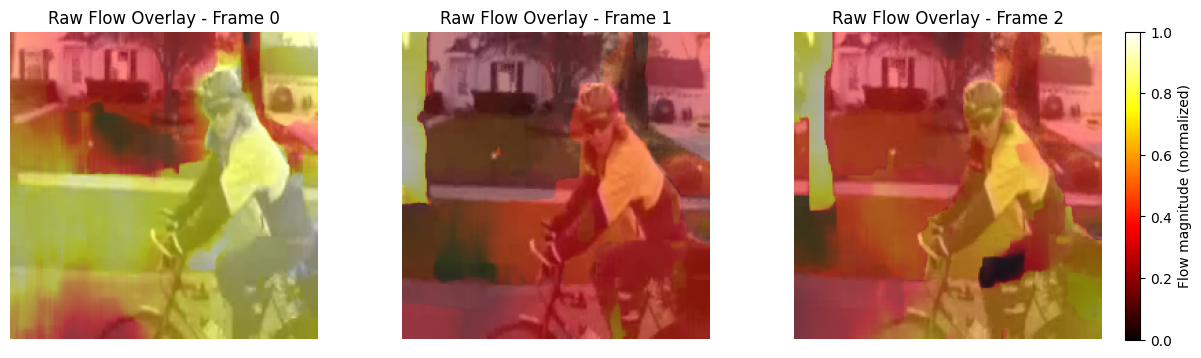

In [18]:
# Uses the same flow values already loaded in `flow`

alpha = 0.5
cmap = plt.get_cmap("hot")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, frame_idx in enumerate(frame_chunk_indices):
    img = frames[i].astype(np.float32) / 255.0
    # flow is (T, 2, 224, 224)
    flow_uv = flow[frame_idx]
    flow_mag = torch.norm(flow_uv, dim=0).numpy()
    flow_mag = (flow_mag - flow_mag.min()) / (flow_mag.max() - flow_mag.min() + 1e-8)
    heat = cmap(flow_mag)[..., :3]

    overlay = (1 - alpha) * img + alpha * heat
    overlay = np.clip(overlay, 0, 1)

    axes[i].imshow(overlay)
    axes[i].set_title(f"Raw Flow Overlay - Frame {frame_idx}")
    axes[i].axis("off")

# Add colorbar for flow magnitude (normalized 0–1)
import matplotlib as mpl
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=0, vmax=1))
sm.set_array([])
fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02, label="Flow magnitude (normalized)")

# plt.tight_layout()
plt.show()

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

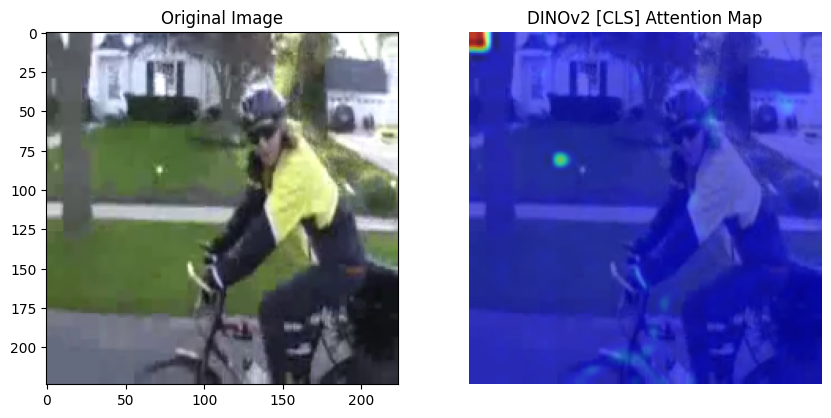

In [38]:
#now get the dinov2-base-with-registers final layer cls pathces attention Map

model_name = "facebook/dinov2-base"
dino = AutoModel.from_pretrained(model_name, output_attentions=True).eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dino = dino.to(device)

dino_transform = v2.Compose([
    v2.ConvertImageDtype(torch.float32),
    v2.Resize((518, 518), antialias=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Use the same 3 frames already loaded above
attn_overlays = []
for i, frame_idx in enumerate(frame_chunk_indices):
    frame = frames[i]
    frame_t = v2.functional.to_image(frame)
    frame_t = dino_transform(frame_t).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = dino(frame_t)
        attn = outputs.attentions[-1]  # (1, heads, tokens, tokens) of the last layer. ts model has 14x14 patch size

        '''
        change below for with or without registers..
        '''
        # cls_attn = attn[:, :, 0, 5:] #row is 0, col is everything after 5
        cls_attn = attn[:, :, 0, 1:] 
        #after 5th, ciz cls + 4 registers. Then the actual patches start
        cls_attn = cls_attn.mean(dim=1) #avg across all 12 attention heads. (1, 1369)
        
        grid_size = int(1369 ** 0.5) #37
        cls_attn = cls_attn.reshape(1, 1, grid_size, grid_size)
        cls_attn = F.interpolate(cls_attn, size=(224, 224), mode="bicubic", align_corners=False) #upscaling
        cls_attn = cls_attn.squeeze().cpu().numpy() #(518, 518)
        cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8) #normalize
        
        attn_overlays.append(cls_attn)
        
        # max_attn, _ = cls_attn.max(dim=1)  #[1, 1369]
        # grid_size = int(max_attn.shape[-1] ** 0.5)  # 37
        # max_attn = max_attn.reshape(1, 1, grid_size, grid_size)
        # max_attn = F.interpolate(max_attn, size=(224, 224), mode='bilinear', align_corners=False)
        # max_attn = max_attn.squeeze().cpu().numpy()
        # max_attn = (max_attn - max_attn.min()) / (max_attn.max() - max_attn.min() + 1e-8)

        # attn_overlays.append(max_attn)


img_to_plot = frame.astype(np.float32) / 255.0

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img_to_plot)

plt.subplot(1, 2, 2)
plt.title("DINOv2 [CLS] Attention Map")
plt.imshow(img_to_plot)
plt.imshow(attn_overlays[0], cmap='jet', alpha=0.6) #60% transparency 
plt.axis('off')
plt.show()

In [10]:
%pwd
# %cd DiffTrack

'/data/pbk5339/thesis/DiffTrack'